# Precision on augmented test dataset

Mirrors `19_new_statistics.ipynb` but evaluates on the augmented test split
(`rectangle-augmented/test_mask_dataset.pth`) produced by notebook 22 /
`wings/detection/augment_dataset.py`. Images contain triangle noise, brightness/contrast
jitter and rotations in ±20–45°.

## Load model

In [15]:
from wings.modeling.loss import BCEDiceLoss
from wings.modeling.litnet import LitNet
from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
from wings.modeling.unet import UNet
import torch

mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle' / "mean_shape.pth",
    weights_only=False
)

checkpoint_path = MODELS_DIR / "new_unet" / "unet-final-k5.ckpt"

unet_model = UNet(in_channels=1, out_channels=1, kernel_size=5)
model = LitNet.load_from_checkpoint(
    checkpoint_path, model=unet_model, criterion=BCEDiceLoss(), strict=False
)
model.eval()
print("Model loaded.")

Model loaded.


## Load augmented test dataset

In [16]:
test_dataset = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle-augmented" / "test_mask_dataset.pth",
    weights_only=False,
)
print(f"Test samples: {len(test_dataset)}")

Test samples: 4344


## Evaluate

In [17]:
from wings.gpa import recover_order, center_shape, normalize_shape, procrustes_align
from wings.visualizing.image_preprocess import final_coords
from wings.gpa import handle_coordinates
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

original_labels  = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices   = [[] for _ in range(5)]

for idx, (image, _, coords, (x_size, y_size)) in enumerate(tqdm(test_dataset, desc="Evaluating")):
    image = image.to(device).unsqueeze(0)
    with torch.no_grad():
        output = model(image)
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    orig = coords.view(-1, 2)

    points_indices[idx_group].append(idx)
    original_labels[idx_group].append(orig.cpu().numpy())
    predicted_labels[idx_group].append(reordered)

original_labels  = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in original_labels]
predicted_labels = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in predicted_labels]

total_samples_num  = len(test_dataset)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])

print(f"Total samples: {total_samples_num}")
print(f"Failed masks:  {failed_samples_num}")

for i, n_pts in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_pts}.shape = {predicted_labels[i].shape}")

Evaluating: 100%|██████████| 4344/4344 [06:36<00:00, 10.96it/s]

Total samples: 4344
Failed masks:  3090
predicted_labels_17.shape = (1755, 19, 2)
predicted_labels_18.shape = (853, 19, 2)
predicted_labels_19.shape = (1254, 19, 2)
predicted_labels_20.shape = (380, 19, 2)
predicted_labels_21.shape = (102, 19, 2)


## Per-group error statistics

In [18]:
errors = []
for i in range(5):
    if predicted_labels[i].shape[0] == 0 or original_labels[i].shape[0] == 0:
        errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(predicted_labels[i] - original_labels[i], axis=2)
    errors.append(err)

for i, n_pts in enumerate(range(17, 22)):
    if errors[i].size == 0:
        print(f"{n_pts}-point group: no samples.")
        continue
    print(f"mean{n_pts}={errors[i].mean():.4f}\tmedian{n_pts}={np.median(errors[i]):.4f}\t\timages={len(errors[i])}")

all_errors = np.concatenate([e.flatten() for e in errors if e.size > 0])
if all_errors.size > 0:
    print(f"\nGLOBAL MEAN ERROR   = {all_errors.mean():.4f}")
    print(f"GLOBAL MEDIAN ERROR = {np.median(all_errors):.4f}")
else:
    print("No valid error data.")

mean17=41.7648	median17=5.9048		images=1755
mean18=3.7939	median18=1.4642		images=853
mean19=4.6117	median19=1.4098		images=1254
mean20=3.2287	median20=1.3974		images=380
mean21=6.0280	median21=1.5041		images=102

GLOBAL MEAN ERROR   = 19.3734
GLOBAL MEDIAN ERROR = 1.7241


## Export per-landmark errors to CSV

Writes `reports/landmark_errors_augmented.csv` and `reports/landmark_error_histogram_augmented.csv`.

In [19]:
import pandas as pd
from wings.config import REPORTS_DIR

group_labels = ["<18", "18", "19", "20", ">20"]

rows = []
for g in range(5):
    if predicted_labels[g].shape[0] == 0:
        continue
    err = np.linalg.norm(predicted_labels[g] - original_labels[g], axis=2)
    for wing_pos in range(err.shape[0]):
        wing_idx = points_indices[g][wing_pos]
        for lm in range(err.shape[1]):
            rows.append((int(wing_idx), group_labels[g], lm + 1, float(err[wing_pos, lm])))

err_df = pd.DataFrame(rows, columns=["wing_index", "group", "landmark", "error_px"])

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
errors_csv = REPORTS_DIR / "landmark_errors_augmented.csv"
err_df.to_csv(errors_csv, index=False)
print(f"saved {len(err_df)} per-point errors -> {errors_csv}")
err_df.head()

saved 82536 per-point errors -> C:\Users\X\projects\bees\reports\landmark_errors_augmented.csv


,wing_index,group,landmark,error_px
0,2,<18,1,1.523638
1,2,<18,2,1.135793
2,2,<18,3,94.690483
3,2,<18,4,1.650840
4,2,<18,5,0.555281


## Error histogram

saved 6252 bins (width=0.1 px) -> C:\Users\X\projects\bees\reports\landmark_error_histogram_augmented.csv


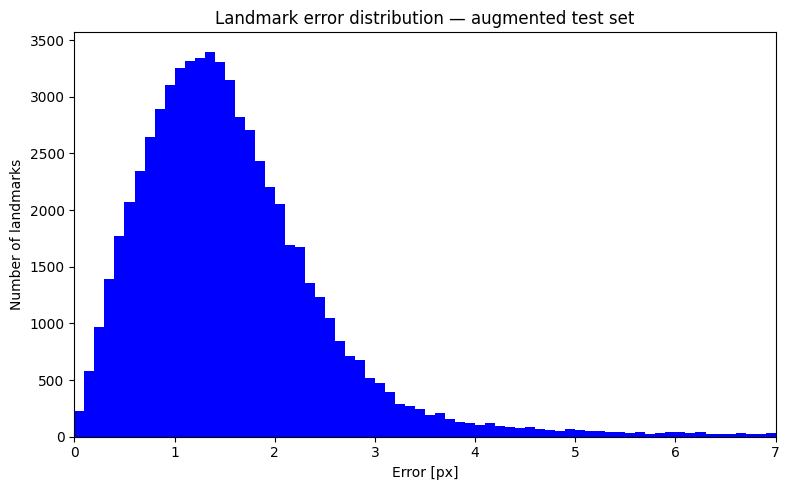

In [20]:
import matplotlib.pyplot as plt

bin_width = 0.1

err_values = err_df["error_px"].to_numpy()
max_edge = np.ceil(err_values.max() / bin_width) * bin_width
edges = np.arange(0.0, max_edge + bin_width, bin_width)
counts, edges = np.histogram(err_values, bins=edges)

hist_df = pd.DataFrame({
    "bin_left":   edges[:-1],
    "bin_center": (edges[:-1] + edges[1:]) / 2,
    "bin_right":  edges[1:],
    "count":      counts,
})
hist_csv = REPORTS_DIR / "landmark_error_histogram_augmented.csv"
hist_df.to_csv(hist_csv, index=False)
print(f"saved {len(hist_df)} bins (width={bin_width} px) -> {hist_csv}")

plt.figure(figsize=(8, 5))
plt.bar(hist_df["bin_center"], hist_df["count"], width=bin_width, color="blue")
plt.xlabel("Error [px]")
plt.ylabel("Number of landmarks")
plt.title("Landmark error distribution — augmented test set")
plt.xlim(0, 7)
plt.tight_layout()
plt.show()

## Visual inspection — random sample

Displays a random test image with the target mask (red) and predicted mask (green) overlaid.

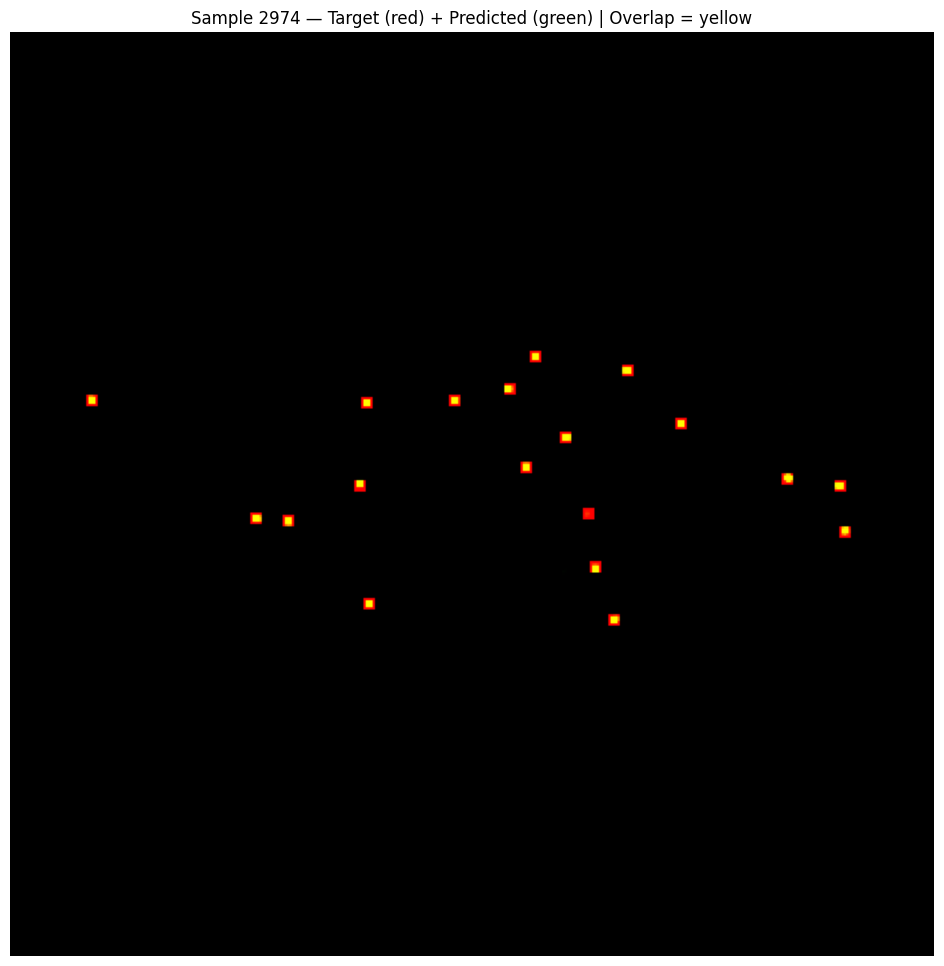

In [21]:
import random

n = random.randint(0, len(test_dataset) - 1)
image, target, coords, (x_size, y_size) = test_dataset[n]

image = image.to(device).unsqueeze(0)
with torch.no_grad():
    output = model(image)

target_np = target.squeeze().detach().cpu().numpy().astype(np.float32)
mask_np   = output.squeeze().detach().cpu().numpy().astype(np.float32)

def norm01(a):
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo + 1e-8) if hi > lo else a - lo

target_np = norm01(target_np)
mask_np   = norm01(mask_np)

overlay = np.zeros((*target_np.shape, 3), dtype=np.float32)
overlay[..., 0] = target_np  # red
overlay[..., 1] = mask_np    # green

plt.figure(figsize=(12, 12))
plt.imshow(np.clip(overlay, 0, 1))
plt.title(f"Sample {n} — Target (red) + Predicted (green) | Overlap = yellow")
plt.axis("off")
plt.show()

## Statistics on rotated images only

Filter the test subset to entries whose filename contains `_rot`, then re-run the
evaluation loop on that slice.

In [22]:
# test_dataset is a torch Subset; the underlying dataset has coords_df with filenames.
base_dataset = test_dataset.dataset
subset_indices = list(test_dataset.indices)

rotated_indices = [
    i for i in subset_indices
    if "_rot" in base_dataset.coords_df.loc[i, "file"]
]

print(f"Total test samples:   {len(subset_indices)}")
print(f"Rotated test samples: {len(rotated_indices)}")

Total test samples:   4344
Rotated test samples: 2147


In [23]:
rot_original_labels  = [[] for _ in range(5)]
rot_predicted_labels = [[] for _ in range(5)]
rot_points_indices   = [[] for _ in range(5)]

for idx in tqdm(rotated_indices, desc="Evaluating rotated"):
    image, _, coords, (x_size, y_size) = base_dataset[idx]
    image = image.to(device).unsqueeze(0)
    with torch.no_grad():
        output = model(image)
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    orig = coords.view(-1, 2)

    rot_points_indices[idx_group].append(idx)
    rot_original_labels[idx_group].append(orig.cpu().numpy())
    rot_predicted_labels[idx_group].append(reordered)

rot_original_labels  = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in rot_original_labels]
rot_predicted_labels = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in rot_predicted_labels]

rot_failed = sum(len(rot_points_indices[i]) for i in [0, 1, 3, 4])
print(f"Failed masks (rotated): {rot_failed}")

for i, n_pts in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_pts}.shape = {rot_predicted_labels[i].shape}")

Evaluating rotated: 100%|██████████| 2147/2147 [04:34<00:00,  7.83it/s]

Failed masks (rotated): 1892
predicted_labels_17.shape = (1434, 19, 2)
predicted_labels_18.shape = (237, 19, 2)
predicted_labels_19.shape = (255, 19, 2)
predicted_labels_20.shape = (151, 19, 2)
predicted_labels_21.shape = (70, 19, 2)


In [24]:
rot_errors = []
for i in range(5):
    if rot_predicted_labels[i].shape[0] == 0 or rot_original_labels[i].shape[0] == 0:
        rot_errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(rot_predicted_labels[i] - rot_original_labels[i], axis=2)
    rot_errors.append(err)

for i, n_pts in enumerate(range(17, 22)):
    if rot_errors[i].size == 0:
        print(f"{n_pts}-point group: no samples.")
        continue
    print(f"mean{n_pts}={rot_errors[i].mean():.4f}\tmedian{n_pts}={np.median(rot_errors[i]):.4f}\t\timages={len(rot_errors[i])}")

rot_all_errors = np.concatenate([e.flatten() for e in rot_errors if e.size > 0])
if rot_all_errors.size > 0:
    print(f"\nGLOBAL MEAN ERROR   (rotated) = {rot_all_errors.mean():.4f}")
    print(f"GLOBAL MEDIAN ERROR (rotated) = {np.median(rot_all_errors):.4f}")
else:
    print("No valid error data.")

mean17=50.4007	median17=33.3578		images=1434
mean18=7.0995	median18=1.6980		images=237
mean19=9.6284	median19=1.6672		images=255
mean20=5.3524	median20=1.5829		images=151
mean21=7.2687	median21=1.5445		images=70

GLOBAL MEAN ERROR   (rotated) = 36.2038
GLOBAL MEDIAN ERROR (rotated) = 2.7500


## Statistics on non-rotated (original) images only

In [25]:
nonrotated_indices = [
    i for i in subset_indices
    if "_rot" not in base_dataset.coords_df.loc[i, "file"]
]

print(f"Non-rotated test samples: {len(nonrotated_indices)}")

Non-rotated test samples: 2197


In [26]:
nr_original_labels  = [[] for _ in range(5)]
nr_predicted_labels = [[] for _ in range(5)]
nr_points_indices   = [[] for _ in range(5)]

for idx in tqdm(nonrotated_indices, desc="Evaluating non-rotated"):
    image, _, coords, (x_size, y_size) = base_dataset[idx]
    image = image.to(device).unsqueeze(0)
    with torch.no_grad():
        output = model(image)
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    orig = coords.view(-1, 2)

    nr_points_indices[idx_group].append(idx)
    nr_original_labels[idx_group].append(orig.cpu().numpy())
    nr_predicted_labels[idx_group].append(reordered)

nr_original_labels  = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in nr_original_labels]
nr_predicted_labels = [np.stack(l) if len(l) > 0 else np.empty((0, 19, 2)) for l in nr_predicted_labels]

nr_failed = sum(len(nr_points_indices[i]) for i in [0, 1, 3, 4])
print(f"Failed masks (non-rotated): {nr_failed}")

for i, n_pts in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_pts}.shape = {nr_predicted_labels[i].shape}")

Evaluating non-rotated: 100%|██████████| 2197/2197 [02:24<00:00, 15.16it/s]

Failed masks (non-rotated): 1198
predicted_labels_17.shape = (321, 19, 2)
predicted_labels_18.shape = (616, 19, 2)
predicted_labels_19.shape = (999, 19, 2)
predicted_labels_20.shape = (229, 19, 2)
predicted_labels_21.shape = (32, 19, 2)


In [27]:
nr_errors = []
for i in range(5):
    if nr_predicted_labels[i].shape[0] == 0 or nr_original_labels[i].shape[0] == 0:
        nr_errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(nr_predicted_labels[i] - nr_original_labels[i], axis=2)
    nr_errors.append(err)

for i, n_pts in enumerate(range(17, 22)):
    if nr_errors[i].size == 0:
        print(f"{n_pts}-point group: no samples.")
        continue
    print(f"mean{n_pts}={nr_errors[i].mean():.4f}\tmedian{n_pts}={np.median(nr_errors[i]):.4f}\t\timages={len(nr_errors[i])}")

nr_all_errors = np.concatenate([e.flatten() for e in nr_errors if e.size > 0])
if nr_all_errors.size > 0:
    print(f"\nGLOBAL MEAN ERROR   (non-rotated) = {nr_all_errors.mean():.4f}")
    print(f"GLOBAL MEDIAN ERROR (non-rotated) = {np.median(nr_all_errors):.4f}")
else:
    print("No valid error data.")

mean17=5.5722	median17=1.4820		images=321
mean18=2.5221	median18=1.4002		images=616
mean19=3.3312	median19=1.3594		images=999
mean20=1.8284	median20=1.3006		images=229
mean21=3.3139	median21=1.4306		images=32

GLOBAL MEAN ERROR   (non-rotated) = 3.2749
GLOBAL MEDIAN ERROR (non-rotated) = 1.3810
